## 8장 확률적 경사 하강법

### 1. SGDClassfier (확률적 경사 하강 분류 모델)

1.1 데이터를 준비한다

In [1]:
# 필요한 라이브러리를 임포트한다.
from google.colab import files
import io
import pandas as pd
import numpy as np

# files.upload()에 의해 [파일 선택] 버튼이 생성된다.
uploaded = files.upload()

Saving fish.csv to fish.csv


In [2]:
# read_csv()으로 업로드된 파일을 Byte 단위로 읽어서 데이터프레임을 생성한다.
fish = pd.read_csv(io.BytesIO(uploaded['fish.csv']))

# fish 데이터프레임의 기본 정보를 확인한다.
fish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    object 
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), object(1)
memory usage: 7.6+ KB


In [3]:
# Species열은 타깃데이터로, 나머지 5개열은 입력데이터로써 넘파이 배열로 만든다.
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
fish_target = fish['Species'].to_numpy()

In [4]:
# 사이킷런의 train_test_split()로 훈련세트와 테스트세트를 만든다.
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42
)

1.2 데이터 전처하기

In [5]:
# StandardScaler 클래스를 이용해서 표준화 전처리를 수행한다.
from sklearn.preprocessing import StandardScaler

# 객체 모델을 만들고 훈련시킨다.
ss = StandardScaler()
ss.fit(train_input)

# 훈련세트의 통계값으로 테스트세트를 변환해야한다.
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

1.3 SGDClassifier 모델의 훈련 및 평가하기

In [6]:
# 사이킷런에서 확률적 경사 하강법을 제공하는 대표적인
# 분류용 클래스는 SGDClassifier 이다.
from sklearn.linear_model import SGDClassifier

In [7]:
# loss = 'log'은 로지스틱 손실함수를 지정하는 것이다.
# max_liter=10 은 수행할 에포크 횟수를 지정하는 것이다.
sc = SGDClassifier(loss='log', max_iter=10, random_state=42)
sc.fit(train_scaled, train_target)

# 훈련 후 훈련세트와 테스트세트의 정확도 점수를 출력한다.
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.773109243697479
0.775


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_stochastic_gradient.py:557: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)


1.4 SDGClassfier 모델의 점진적 훈련시키기

In [8]:
# 모델 객체를 다시 만들지 않고 훈련한 모델 sc를 추가로 훈련시킨다.
# 모델을 이어서 훈련할 때는 partial_fit()를 사용한다.
sc.partial_fit(train_scaled, train_target)

# 훈련 후 훈련세트와 테스트세트의 정확도 점수를 출력한다.
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.8151260504201681
0.825


### 2. 에포크와 과대/과소적합

In [9]:
import numpy as np
# SGDClassfier 모델 객체를 만든다.
# loss='log'은 로지스틱 손실함수를 지정하는 것이다.
sc = SGDClassifier(loss='log', random_state=42)

# 에포크마다 훈련점수와 테스트점수를 기록하기 위한 2개의 리스트이다.
train_score = []
test_score = []

In [10]:
# np.unique()으로 train_target에 있는 7개 생선의 목록을 만든다.
classes = np.unique(train_target)

# 300번의 에포크 동안 훈련을 반복하여 진행한다.
# partial_fit()만 사용하려면 훈련세트에 있는 전체클래스의 레이블(classes=classes)을
# partial_fit()에 전달한다.
for _ in range(0,300):        # 파이썬에서 언더스코어(_)는 어떤 특정값을 무시하기 위한 용도로 사용되기도 한다. 값이 필요하지 않거나 사용되지 않는 값을 _에 할당하기만 하면 된다.
  sc.partial_fit(train_scaled, train_target, classes=classes)
  # 반복마다 훈련점수와 테스트점수를 저장한다.
  train_score.append(sc.score(train_scaled, train_target))
  test_score.append(sc.score(test_scaled, test_target))

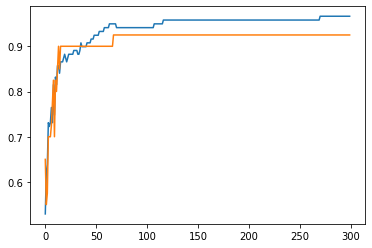

In [11]:
import matplotlib.pyplot as plt
# 300번의 에포크 동안 기록한 훈련점수와 테스트점수를 그래프로 그린다.
plt.plot(train_score)
plt.plot(test_score)
plt.show()

In [12]:
# 반복횟수를 100에 맞추어 모델을 다시 훈련시킨다.
sc = SGDClassifier(loss='log', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)

# 훈련점수와 테스트점수를 출력한다.
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925
